# Проект. Анализ пользовательской активности и оценка результатов A/B-тестирования

# Часть 1. Проверка статистических гипотез и анализ A/B-тестирования

В данном проекте рассмотрены две прикладные задачи продуктовой аналитики.

Первая часть посвящена исследованию пользовательской активности сервиса Яндекс Книги. Цель анализа — определить, существуют ли статистически значимые различия в поведении пользователей из Москвы и Санкт-Петербурга на основе данных о времени чтения и прослушивания книг.

Во второй части проекта проводится анализ результатов A/B-тестирования новой версии сайта интернет-магазина BitMotion Kit. В рамках исследования оценивается корректность проведения эксперимента, анализируется поведение пользователей в контрольной и экспериментальной группах, рассчитывается изменение конверсии и выполняется статистическая проверка полученных результатов.

Для решения поставленных задач использованы инструменты Python и библиотеки Pandas, SciPy, Statsmodels и Matplotlib.


## Цели и задачи проекта
[Вернуться к оглавлению](#contents)

Цель - проверить гипотезу о неравенстве времени чтения и прослушивания книг в приложении Яндекс Книги пользователей из Москвы и Санкт-Петербурга. По результатам анализа данных составить аналитическую записку.

Задачи:
- Загрузить данные и ознакомиться с ними;
- Провести предобработку данных (дубликаты, выбросы);
- Проверить гипотезу о неравенстве;
- Составить аналитическую записку.

## Описание данных

Мы будем работать с таблицей:
- `/datasets/yandex_knigi_data.csv` - данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания)

Поля таблицы:
- `city` - город пользователя;
- `puid` - уникальный идентификатор;
- `hours` - сумма часов чтения и прослушивания.

<a id="contents"></a>
## Оглавление
1. [Часть 1. Проверка статистических гипотез и анализ A/B-тестирования](#Часть-1.-Проверка-статистических-гипотез-и-анализ-A/B-тестирования)
1. [Цели и задачи проекта](#Цели-и-задачи-проекта)
2. [Описание данных](#Описание-данных)
4. [Загрузка данных и знакомство с ними](#Загрузка-данных-и-знакомство-с-ними)
5. [Предобработка данных](#Предобработка-данных)
8. [Проверка гипотезы в Python](#Проверка-гипотезы-в-Python)
9. [Аналитическая записка](#Аналитическая-записка)
10. [Часть 2. Анализ результатов A/B тестирования](#Часть-2.-Анализ-результатов-A/B-тестирования)
14. [Оценка результатов A/B-тестирования](#Оценка-результатов-A/B-тестирования)
15. [Выводы по проведённой оценке результатов A/B тестирования](#Выводы-по-проведённой-оценке-результатов-A/B-тестирования)


## Загрузка данных и знакомство с ними

Загружаем необходимые для работы библиотеки и изучаем текущее состояние данных

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize
from statsmodels.stats.proportion import proportions_ztest

import warnings
warnings.filterwarnings('ignore')

In [2]:
users_activity = pd.read_csv('/data_knigi_data.csv')
display(users_activity.head(5), users_activity.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


None

## Предобработка данных
[Вернуться к оглавлению](#contents)

Удалим столбец `Unnamed: 0` из датафрейма

In [3]:
users_activity = users_activity.drop('Unnamed: 0', axis = 1)

###  Проверка наличия дубликатов

In [4]:
count_nunique = users_activity['puid'].nunique()

count_df = len(users_activity['puid'])

if count_df == count_nunique:
    print(f'Дубликаты отсутствуют')
    
if count_df != count_nunique:
    print(f'Дубликаты присутствуют в количестве: {count_df - count_nunique}')

Дубликаты присутствуют в количестве: 244


In [5]:
users_activity[
    users_activity['puid'].duplicated(keep=False)
].sort_values(by='puid').head(10)

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
6279,Санкт-Петербург,10597984,9.041320
150,Москва,10815097,9.086655
6283,Санкт-Петербург,10815097,0.323291
187,Москва,13626259,21.104167
6300,Санкт-Петербург,13626259,1.648434


Одни и теже пользователи `puid` состоят в двух группах (городах) одновременно, что недопустимо для дальнейшего исследования. Было принято решение удалить дубликаты по полю `puid`.

In [6]:
duplicate_users = (
    users_activity.groupby('puid')['city']
    .nunique()
)
duplicate_users = duplicate_users[duplicate_users > 1].index

users_activity = users_activity[
    ~users_activity['puid'].isin(duplicate_users)
]

users_activity['puid'].duplicated().sum()

0

### Сравнение размеров групп, их статистик и распределений

In [7]:
size_groups = users_activity.groupby('city')['puid'].nunique()
size_groups

city
Москва             5990
Санкт-Петербург    2306
Name: puid, dtype: int64

In [8]:
users_activity.groupby('city')['hours'].describe()

,count,mean,std,min,25%,50%,75%,max
city,,,,,,,,
Москва,5990.0,10.848192,36.925622,0.000022,0.057042,0.888232,5.933439,857.209373
Санкт-Петербург,2306.0,11.264433,39.831755,0.000025,0.060173,0.875355,6.138424,978.764775


Изучив статистические данные 2-х групп стоит сказать, что значения активности пользователей СПб немного выше значений московских пользователей, однако особых различий в стат.значениях не наблюдается. Важно отметить большую разницу между средним (mean) и медианой (50%) в значениях обеих групп. Это говорит о большом количестве выбросов.Изучим выбросы 2-х групп

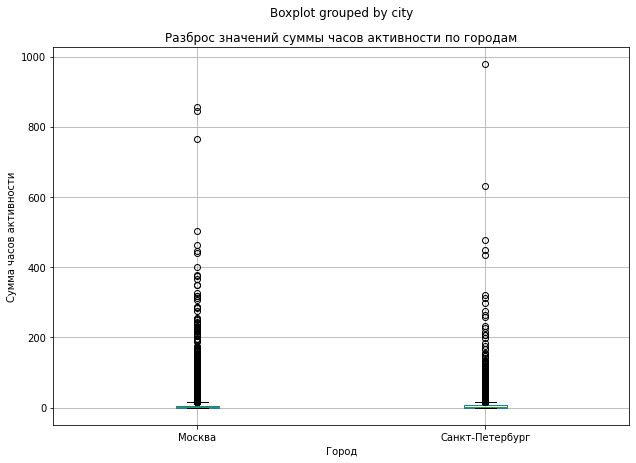

In [9]:
users_activity.boxplot(column='hours', by='city', figsize=(10, 7))
plt.title('Разброс значений суммы часов активности по городам')
plt.xlabel('Город')
plt.ylabel('Сумма часов активности')

plt.show()

Изучим распределения 2-х групп

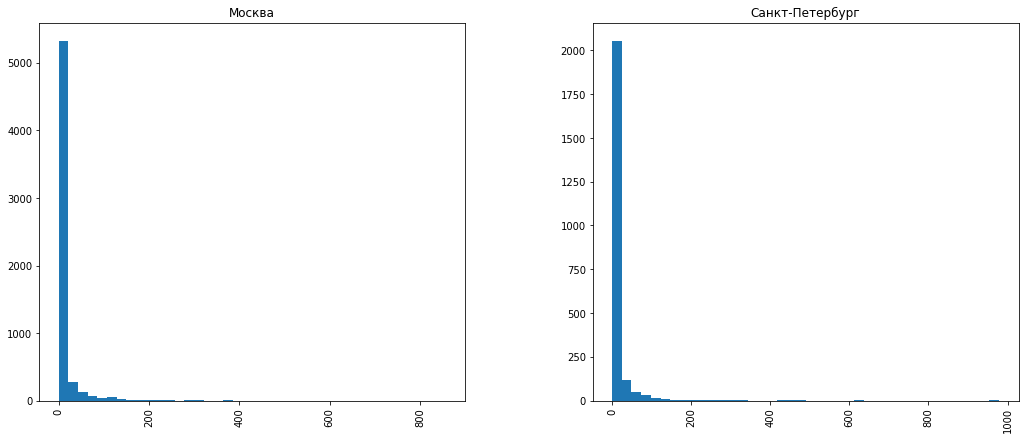

In [10]:
histogramm = users_activity.hist(
    bins=40, 
    column='hours', 
    by='city', 
    figsize=(17, 7)
)

plt.show()

Изучив гистограммы распределения суммы часов активности по городам и диаграмму выбросов можно заметить ярко выраженную правостороннюю асимметрию, что говорит нам о том, что основная часть пользователей проводит малое кол-во часов в приложении. Также стоит обратить внимание на сходство распределений и выбросов в обоих группах (Москвы и СПб), что позволяет нам принять решение выборе стат. теста. Распределения имеют выраженную правостороннюю асимметрию и содержат выбросы. Дополнительно размеры групп существенно различаются. Поэтому для проверки гипотезы выбран t-тест Уэлча, который не требует равенства дисперсий.

## Проверка гипотезы в Python
[Вернуться к оглавлению](#contents)

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [11]:
SPb = users_activity[users_activity['city'] == 'Санкт-Петербург']['hours']
Mck = users_activity[users_activity['city'] == 'Москва']['hours']

stat_welsh_ttest, p_value_welsh_ttest = ttest_ind(
    SPb,
    Mck,
    equal_var = False,
    alternative = 'greater'
)
alpha = 0.05
if p_value_welsh_ttest > alpha:
    print(f'p_value = {round(p_value_welsh_ttest, 2)}, нулевая гипотеза находит подтверждение!')
else:
    print(f'p_value = {round(p_value_welsh_ttest, 2)}, отвергаем нулевую гипотезу.')

p_value = 0.33, нулевая гипотеза находит подтверждение!


### Аналитическая записка
[Вернуться к оглавлению](#contents)

Мы провели стат. т-тест Уэлча, выбранный уровень статистической значимости (`alpha`) составил 0.05. Результат теста (`p_value`) составил 0.33, что превышает уровень стат. значимости и не даёт нам статистически значимых оснований отвергнуть нулевую гипотезу. По результатам стат. теста мы можем утверждать, что средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается. По всей видимости, пользователи СПб и Москвы в среднем пользуются приложением Яндекс Книги равное кол-во времени (различие слишком мало, чтобы мы могли считать его стат. значимым).

----

## Часть 2. Анализ результатов A/B-тестирования
[Вернуться к оглавлению](#contents)

Интернет-магазин BitMotion Kit специализируется на продаже геймифицированных товаров для людей, ведущих здоровый образ жизни. Среди наиболее популярных продуктов компании — эспандер со счётчиком повторений и подстольный велотренажёр с поддержкой Bluetooth.

В процессе развития продукта компания столкнулась с проблемой: пользователи отмечали сложность интерфейса интернет-магазина, что могло негативно влиять на конверсию в покупку.

Для решения этой задачи была разработана новая версия сайта с упрощённым пользовательским интерфейсом. Перед масштабным внедрением изменений компания провела A/B-тестирование на части аудитории.

В рамках данного проекта проводится оценка корректности проведения эксперимента и анализ его результатов с целью определить, оказало ли изменение интерфейса статистически значимое влияние на конверсию пользователей.

В нашем распоряжении находятся данные о действиях пользователей, распределении их по экспериментальным группам, а также техническое задание на проведение тестирования.


## Цели исследования



Цель - провести оценку результатов A/B-теста (тестирование новой версии сайта, гипотеза о повышении кол-ва пользователей, которые совершат покупку) для интернет-магазина BitMotion Kit.

## Загрузим данные, оценим их целостность.


In [12]:
participants = pd.read_csv('data_ab_test_participants.csv')
events = pd.read_csv('data_ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [13]:
display(participants.head(5), events.head(5), participants.info(), events.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


None

None

## По таблице `ab_test_participants` оценим корректность проведения теста:

   Проверяем:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [14]:
participants_euTest = participants[participants['ab_test'] == 'interface_eu_test']
participants_sTest = participants[participants['ab_test'] == 'recommender_system_test']

count_of_groups_euTest = participants_euTest.groupby('group')['user_id'].nunique()
count_of_groups_sTest = participants_sTest.groupby('group')['user_id'].nunique()

duplicates_in_df_sTest = participants_sTest['user_id'].duplicated().sum()
duplicates_in_df_euTest = participants_euTest['user_id'].duplicated().sum()

display(count_of_groups_euTest, count_of_groups_sTest, duplicates_in_df_sTest, duplicates_in_df_euTest)

group
A    5383
B    5467
Name: user_id, dtype: int64

group
A    2747
B     928
Name: user_id, dtype: int64

0

0

Мы получили размеры групп А и В в каждом тесте, а также убедились в отсутствии дубликатов в каждом тесте. Теперь нам предстоит проверить наличие пользователей, входящих в 2 теста одновременно.

In [15]:
users_in_twoTests = participants.groupby('user_id')['ab_test'].nunique()
users_in_twoTests.unique()

array([1, 2])

Видим, что есть пользователи, входящие сразу в 2 теста. Было принято решение об удалении пользователей, входящих в 2 теста одновременно.

In [16]:
users_in_twoTests = users_in_twoTests[users_in_twoTests > 1].index

participants = participants[
    ~participants['user_id'].isin(users_in_twoTests)
]

proverka = participants.groupby('user_id')['ab_test'].nunique()
print(proverka.unique())

[1]


3\.2 Проанализируем данные о пользовательской активности по таблице `ab_test_events`:

- оставим только события, связанные с участвующими в изучаемом тесте пользователями;

Перед работой с датафреймом `events` проверим его на наличие дубликатов.

In [17]:
events.duplicated().sum()

36318

In [18]:
events[events.duplicated(keep = False)].head(10)

,user_id,event_dt,event_name,details
49,A39D63750BBE9B34,2020-12-01 00:08:24,login,NaN
50,A39D63750BBE9B34,2020-12-01 00:08:24,login,NaN
131,631020621D23464A,2020-12-01 00:25:03,login,NaN
132,631020621D23464A,2020-12-01 00:25:03,login,NaN
277,AD6541E75198ABEF,2020-12-01 00:48:46,login,NaN
278,AD6541E75198ABEF,2020-12-01 00:48:46,login,NaN
389,ADBBC43BED1249C8,2020-12-01 01:06:02,product_cart,NaN
390,ADBBC43BED1249C8,2020-12-01 01:06:02,product_cart,NaN
445,928AD890A8E7BDE7,2020-12-01 01:11:10,login,NaN
446,928AD890A8E7BDE7,2020-12-01 01:11:10,login,NaN


После изучения стало ясно, что мы имеем дело с полными дубликатами, которые подлежат удалению.

In [19]:
events = events.drop_duplicates()

In [20]:
participants_eu_test = participants[participants['ab_test'] == 'interface_eu_test']
participants_s_test = participants[participants['ab_test'] == 'recommender_system_test']

events_eu_test = events[events['user_id'].isin(participants_eu_test['user_id'])]
events_s_test = events[events['user_id'].isin(participants_s_test['user_id'])]

Оценим достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%,

- MDE = 0.03 .

In [21]:
alpha = 0.05
power = 0.8
p_1 = 0.3
p_2 = 0.33

effect_size = proportion_effectsize(p_1, p_2)

analysis = NormalIndPower()

sample_size = analysis.solve_power(
    effect_size = effect_size,
    alpha = alpha,
    power = power,
    ratio = 1
)

print(f'Необходимый минимальный размер выборки для каждой группы = {round(sample_size, 2)}')

Необходимый минимальный размер выборки для каждой группы = 3761.6


- определим горизонт анализа: рассчитаем время (лайфтайм) совершения события пользователем после регистрации и оставим только те события, которые были выполнены в течение первых семи дней с момента регистрации

In [22]:
registration_dates_eu_test = (
    events_eu_test[
        events_eu_test['event_name'] == 'registration'
    ][['user_id', 'event_dt']]
    .rename(columns = {'event_dt' : 'registration_dt'})
)
registration_dates_s_test = (
    events_s_test[
        events_s_test['event_name'] == 'registration'
    ][['user_id', 'event_dt']]
    .rename(columns = {'event_dt' : 'registration_dt'})
)

In [23]:
events_eu_test = events_eu_test.merge(registration_dates_eu_test, on = 'user_id', how = 'left')
events_s_test = events_s_test.merge(registration_dates_s_test, on = 'user_id', how = 'left')

In [24]:
events_eu_test['day_after_registration'] = (events_eu_test['event_dt'] - events_eu_test['registration_dt']).dt.days
events_s_test['day_after_registration'] = (events_s_test['event_dt'] - events_s_test['registration_dt']).dt.days

In [25]:
events_eu_test = events_eu_test[events_eu_test['day_after_registration'] <= 7]
events_s_test = events_s_test[events_s_test['day_after_registration'] <= 7]

- рассчитаем для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей

In [26]:
events_eu_test = events_eu_test.merge(participants_eu_test[['user_id', 'group']], on = 'user_id', how = 'left')

In [27]:
general_count_usersInGroups = events_eu_test.groupby('group')['user_id'].nunique()

events_eu_test_purchase = events_eu_test[events_eu_test['event_name'] == 'purchase']
count_usersInPurchase_group = events_eu_test_purchase.groupby('group')['user_id'].nunique()

print(f'Общее кол-во посетителей для каждой группы: {general_count_usersInGroups}') 
print(f'Кол-во посетителей сделавших покупку для каждой группы: {count_usersInPurchase_group}')

Общее кол-во посетителей для каждой группы: group
A    4952
B    5011
Name: user_id, dtype: int64
Кол-во посетителей сделавших покупку для каждой группы: group
A    1435
B    1562
Name: user_id, dtype: int64


- сделаем предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной

In [28]:
group_a = 1435 / 4952
group_b = 1562 / 5011

print(f'Конверсия группы А: {round(group_a * 100, 2)}%')
print(f'Конверсия группы В: {round(group_b * 100, 2)}%')

Конверсия группы А: 28.98%
Конверсия группы В: 31.17%


Предварительный анализ показывает, что группа В демонстрирует более высокую конверсию в сравнении с группой А. Это может свидетельствовать о положительном влиянии нововведения и потенциальной верности альтернативной гипотезы. Однако это требует подтверждения на стат. тесте.

## Оценка результатов A/B тестирования
[Вернуться к оглавлению](#contents)

- Проверим изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез

Формулировка гипотез:

Нулевая гипотеза H0: конверсия группы В не превышает конверсию группы А.

Альтернативная гипотеза H1: конверсия группы В выше конверсии группы А.

Используем статический Z-тест пропорций

In [29]:
n_a, n_b = 4952, 5011
m_a, m_b = 1435, 1562

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative = 'smaller'
)

if p_value_ztest > alpha:
    print(f'p_value = {round(p_value_ztest, 2)}')
    print(f'Нулевая гипотеза находит подтверждение!')
else:
    print(f'p_value = {round(p_value_ztest, 2)}')
    print(f'Нулевая гипотеза не находит подтверждения!')

p_value = 0.01
Нулевая гипотеза не находит подтверждения!


### Выводы по проведённой оценке результатов A/B тестирования
[Вернуться к оглавлению](#contents)

Проведя статистический Z-тест пропорций мы выяснили, что у нас нет статистически значимых оснований принять нулевую гипотезу, различие конверсий между группами можем считать статистически значимым. Фактический рост конверсии составил около 2,2% что ниже ожидаемых 3%, целевой эффект достигнут не полностью.

В качестве рекомендации предлагается пересмотреть улучшения сайта, разработать вторую новую версию, либо же рассмотреть иные способы поднятия коверсии кроме улучшения сайта магазина.